# Part 1 – Data Acquisition, Cleaning and Exploratory Data Analysis

This notebook contains the data cleaning and exploratory data analysis for the Student Performance dataset. The cleaned dataset created here will be used in the later parts of the project for machine learning model development.

## 1. Import Required Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# To display plots inside the notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## 2. Loading the Dataset

In [3]:
# Dataset loading
df = pd.read_csv("../data/student-por.csv", sep=";")

print("Student Performance dataset loaded successfully.")

Student Performance dataset loaded successfully.


## 3. Dataset Inspection

In [6]:
# Display the first five rows
print("First five rows of the dataset:")
display(df.head())

# Display the data types
print("\nData types:")
print(df.dtypes)

# Display the dataset dimensions
print("\nDataset shape (rows, columns):")
print(df.shape)

First five rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Data types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

Dataset shape (rows, columns):
(649, 33)


## 4. Missing Value Analysis

In [7]:
# Count missing values in each column
null_count = df.isnull().sum()

# Calculate missing value percentage
null_percentage = (null_count / len(df)) * 100

# Create a summary table
null_summary = pd.DataFrame({
    "Missing Values": null_count,
    "Percentage (%)": null_percentage.round(2)
})

print("Missing value summary:")
display(null_summary)

Missing value summary:


,Missing Values,Percentage (%)
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


In [8]:
# Identify columns with more than 20% missing values
high_null_columns = null_summary[null_summary["Percentage (%)"] > 20]

if high_null_columns.empty:
    print("No columns have more than 20% missing values.")
else:
    display(high_null_columns)

No columns have more than 20% missing values.


## 5. Duplicate Detection and Removal

In [9]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [10]:
# Store the original number of rows
rows_before = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates()

# Store the new number of rows
rows_after = df.shape[0]

# Calculate how many rows were removed
rows_removed = rows_before - rows_after

print(f"Rows before removing duplicates: {rows_before}")
print(f"Rows after removing duplicates : {rows_after}")
print(f"Duplicate rows removed         : {rows_removed}")

Rows before removing duplicates: 649
Rows after removing duplicates : 649
Duplicate rows removed         : 0


In [11]:
# Check missing value percentage after removing duplicates
null_percentage_after = (df.isnull().sum() / len(df)) * 100

null_summary_after = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": null_percentage_after.round(2)
})

display(null_summary_after)

,Missing Values,Percentage (%)
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


### Interpretation

No duplicate rows were identified in the dataset. Therefore, no records were removed, and the overall data quality remained unchanged.

## 6. Data Type Correction

In [12]:
# Display the current data types
print("Current data types:")
display(df.dtypes)

Current data types:


school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [13]:
# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()

print(f"Memory usage before conversion: {memory_before} bytes")

Memory usage before conversion: 205733 bytes


In [14]:
categorical_columns = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

In [15]:
# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()

print(f"Memory usage before conversion : {memory_before} bytes")
print(f"Memory usage after conversion  : {memory_after} bytes")
print(f"Memory reduced by              : {memory_before - memory_after} bytes")

Memory usage before conversion : 205733 bytes
Memory usage after conversion  : 94762 bytes
Memory reduced by              : 110971 bytes


In [16]:
print("Updated data types:")
display(df.dtypes)

Updated data types:


school        category
sex           category
age              int64
address       category
famsize       category
Pstatus       category
Medu             int64
Fedu             int64
Mjob          category
Fjob          category
reason        category
guardian      category
traveltime       int64
studytime        int64
failures         int64
schoolsup     category
famsup        category
paid          category
activities    category
nursery       category
higher        category
internet      category
romantic      category
famrel           int64
freetime         int64
goout            int64
Dalc             int64
Walc             int64
health           int64
absences         int64
G1               int64
G2               int64
G3               int64
dtype: object

### Interpretation

The dataset's numeric columns were already inferred correctly by pandas. Repetitive text columns were converted from the `object` data type to `category` to improve memory efficiency. The memory usage decreased after the conversion, making the dataset more efficient for further analysis and model training.

## 7. Descriptive Statistics and Skewness Analysis

In [17]:
# Display descriptive statistics for all numeric columns
print("Descriptive Statistics")
display(df.describe())

Descriptive Statistics


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [18]:
# Calculate skewness for all numeric columns

skewness = df.select_dtypes(include=np.number).skew()

skewness_df = pd.DataFrame({
    "Column": skewness.index,
    "Skewness": skewness.values,
    "Absolute Skewness": skewness.abs().values
})

skewness_df = skewness_df.sort_values(
    by="Absolute Skewness",
    ascending=False
)

display(skewness_df)

,Column,Skewness,Absolute Skewness
5,failures,3.092699,3.092699
9,Dalc,2.141913,2.141913
12,absences,2.020694,2.020694
3,traveltime,1.247648,1.247648
6,famrel,-1.105934,1.105934
15,G3,-0.912909,0.912909
4,studytime,0.699619,0.699619
10,Walc,0.635904,0.635904
11,health,-0.500656,0.500656
0,age,0.416795,0.416795


In [19]:
most_skewed = skewness_df.iloc[0]

print("Most skewed numeric column")
print(f"Column : {most_skewed['Column']}")
print(f"Skewness : {most_skewed['Skewness']:.3f}")

Most skewed numeric column
Column : failures
Skewness : 3.093


In [ ]:
## 8. Outlier Detection using the IQR Method

In [20]:
def detect_outliers_iqr(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print("=" * 50)
    print(f"Column : {column}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower}")
    print(f"Upper Bound : {upper}")
    print(f"Number of Outliers : {len(outliers)}")

In [21]:
detect_outliers_iqr("failures")

detect_outliers_iqr("absences")

Column : failures
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Number of Outliers : 100
Column : absences
Q1 : 0.0
Q3 : 6.0
IQR : 6.0
Lower Bound : -9.0
Upper Bound : 15.0
Number of Outliers : 21


## 9. Line Plot

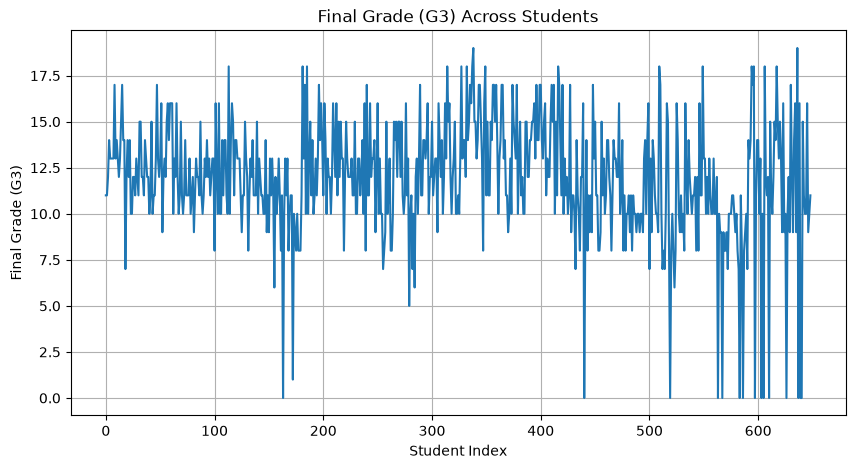

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df["G3"])

plt.title("Final Grade (G3) Across Students")
plt.xlabel("Student Index")
plt.ylabel("Final Grade (G3)")
plt.grid(True)

plt.savefig("../plots/line_plot_g3.png", dpi=300)
plt.show()

## 10. Bar Chart

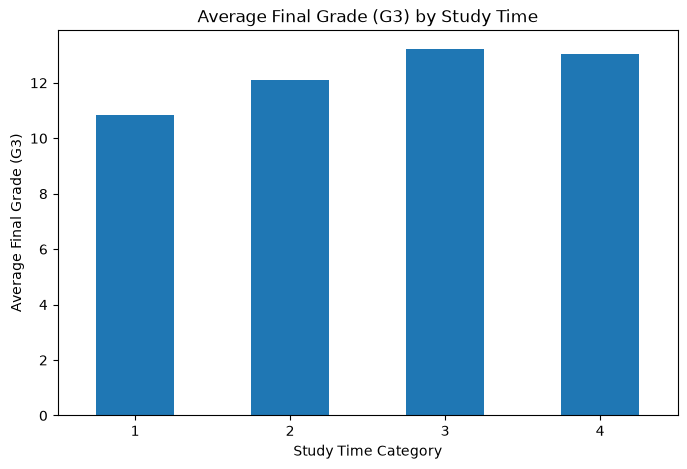

In [ ]:
# Calculate the mean G3 score for each study time category
studytime_mean = df.groupby("studytime")["G3"].mean()

plt.figure(figsize=(8, 5))

studytime_mean.plot(kind="bar")

plt.title("Average Final Grade (G3) by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade (G3)")

plt.xticks(rotation=0)

plt.savefig("../plots/bar_chart_studytime_g3.png", dpi=300)
plt.show()

## 11. Histogram

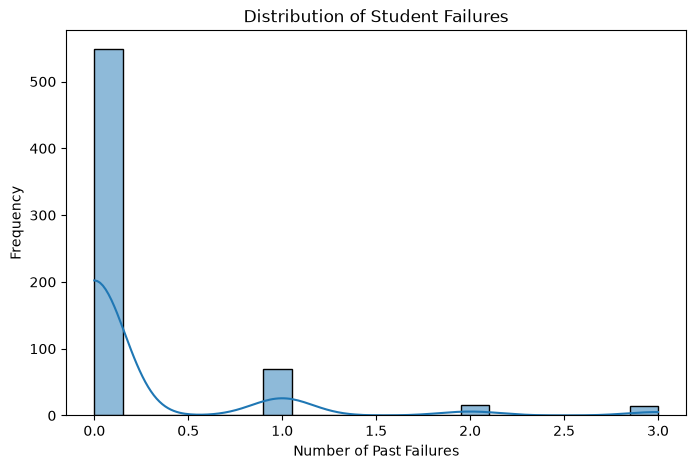

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["failures"], bins=20, kde=True)

plt.title("Distribution of Student Failures")
plt.xlabel("Number of Past Failures")
plt.ylabel("Frequency")

plt.savefig("../plots/histogram_failures.png", dpi=300)
plt.show()

## 12. Scatter Plot

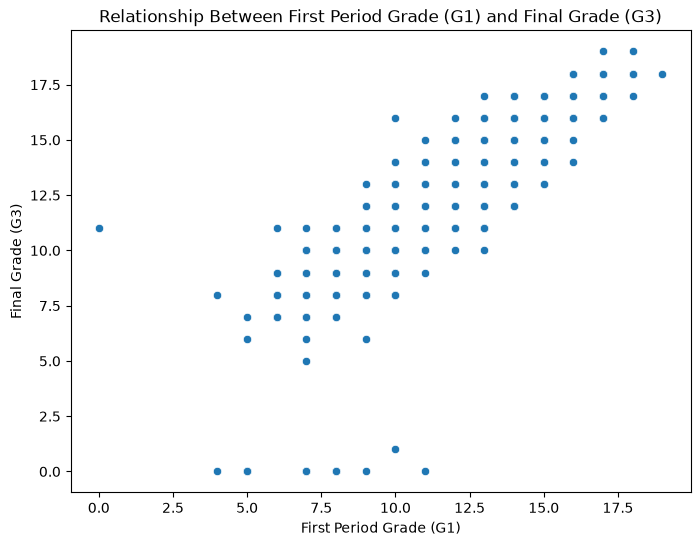

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="G1",
    y="G3"
)

plt.title("Relationship Between First Period Grade (G1) and Final Grade (G3)")
plt.xlabel("First Period Grade (G1)")
plt.ylabel("Final Grade (G3)")

plt.savefig("../plots/scatter_g1_g3.png", dpi=300)
plt.show()

## 13. Box Plot

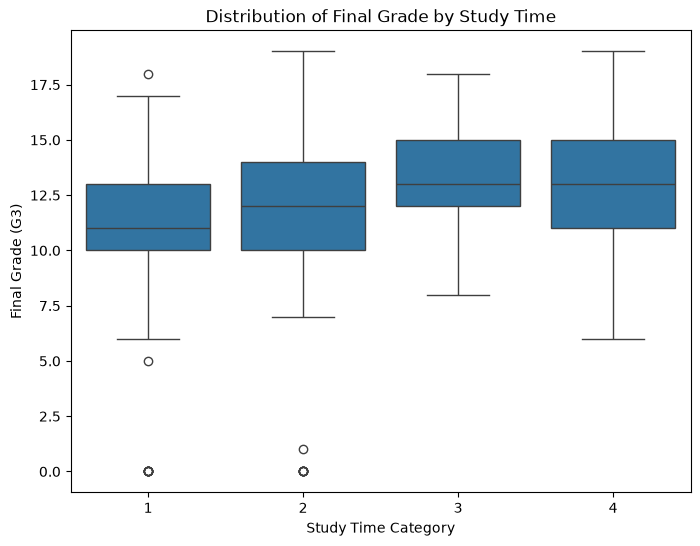

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Distribution of Final Grade by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.savefig("../plots/boxplot_studytime_g3.png", dpi=300)
plt.show()

## 14. Pearson Correlation Heatmap

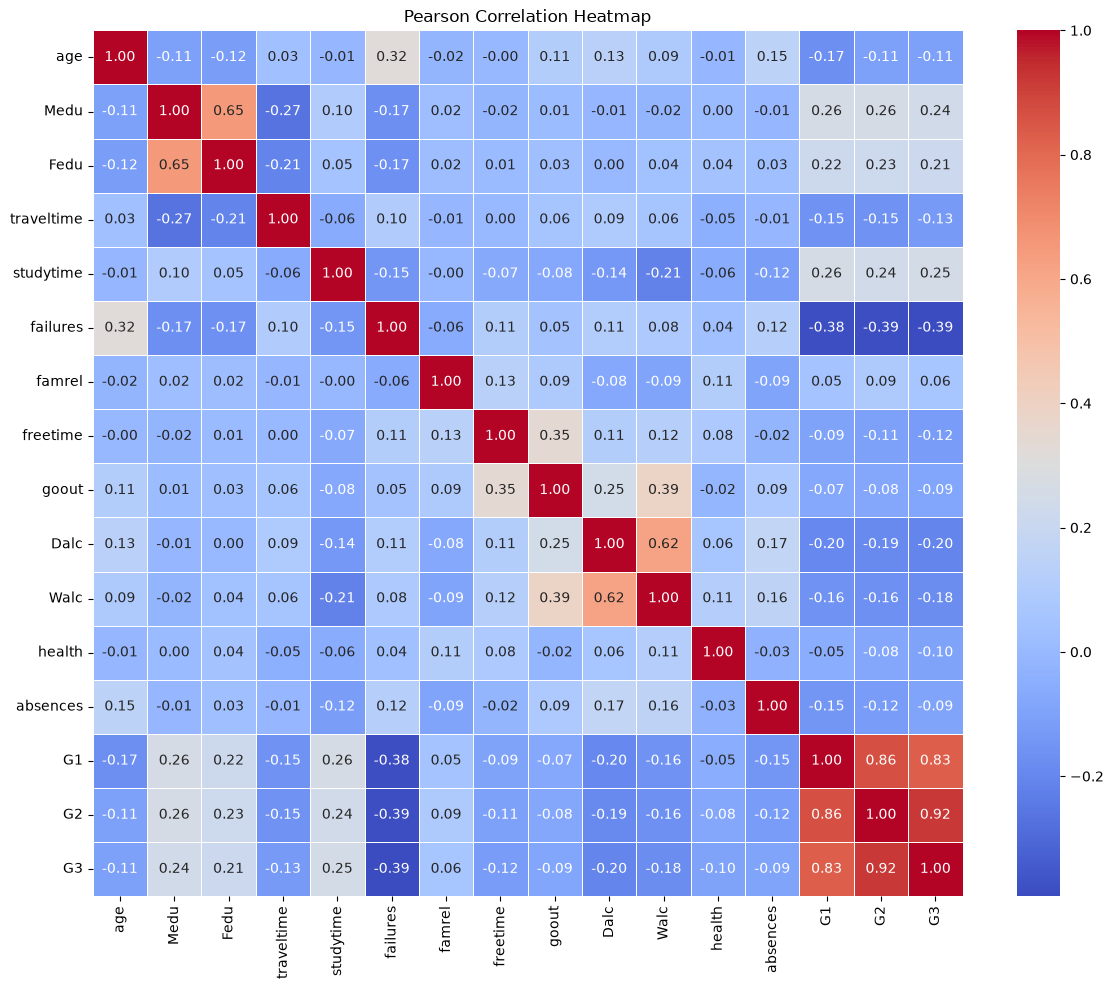

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Compute Pearson correlation matrix
pearson_corr = numeric_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.savefig("../plots/pearson_heatmap.png", dpi=300)
plt.show()

## Identifying the Highest Correlated Pair

In [31]:
corr_matrix = pearson_corr.abs().copy()

# Set self-correlations to zero
for col in corr_matrix.columns:
    corr_matrix.loc[col, col] = 0

# Find highest correlated pair
highest_pair = corr_matrix.unstack().idxmax()
highest_corr = corr_matrix.unstack().max()

print("Highest Correlated Variables")
print("----------------------------")
print(f"Variables : {highest_pair}")
print(f"Correlation : {highest_corr:.3f}")

Highest Correlated Variables
----------------------------
Variables : ('G2', 'G3')
Correlation : 0.919


## 15. Imputation Strategy Comparison

In [32]:
# Two most skewed numerical columns
skewed_columns = ["failures", "Dalc"]

comparison = pd.DataFrame({
    "Mean": [df[col].mean() for col in skewed_columns],
    "Median": [df[col].median() for col in skewed_columns]
}, index=skewed_columns)

print("Mean vs Median Comparison")
display(comparison)

Mean vs Median Comparison


,Mean,Median
failures,0.221880,0.0
Dalc,1.502311,1.0


## Median Imputation Strategy

In [33]:
# Apply median imputation only if missing values exist
for col in skewed_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining Missing Values")
print(df[skewed_columns].isnull().sum())

Remaining Missing Values
failures    0
Dalc        0
dtype: int64


## 16. Spearman Rank Correlation

In [34]:
# Compute Spearman correlation matrix
spearman_corr = numeric_df.corr(method="spearman")

print("Spearman Correlation Matrix")
display(spearman_corr)

Spearman Correlation Matrix


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.102288,-0.110211,0.067122,0.016959,0.290735,-0.019374,-0.009869,0.130536,0.081319,0.094343,-0.018051,0.124260,-0.167373,-0.105595,-0.066277
Medu,-0.102288,1.000000,0.647194,-0.263289,0.098415,-0.208240,0.025087,-0.027895,0.010205,0.001961,-0.018234,0.016112,-0.006011,0.276400,0.285642,0.283925
Fedu,-0.110211,0.647194,1.000000,-0.222034,0.069080,-0.161312,0.021284,-0.000151,0.028787,-0.004897,0.029726,0.046351,0.032025,0.234951,0.246285,0.234633
traveltime,0.067122,-0.263289,-0.222034,1.000000,-0.089387,0.123614,-0.025649,-0.001049,0.040714,0.068463,0.031517,-0.063844,0.022924,-0.166226,-0.166901,-0.146948
studytime,0.016959,0.098415,0.069080,-0.089387,1.000000,-0.160307,0.019370,-0.076496,-0.082318,-0.171309,-0.222088,-0.076732,-0.116945,0.271412,0.259252,0.274712
failures,0.290735,-0.208240,-0.161312,0.123614,-0.160307,1.000000,-0.058723,0.100437,0.041667,0.108862,0.064746,0.041132,0.120908,-0.432432,-0.435741,-0.448360
famrel,-0.019374,0.025087,0.021284,-0.025649,0.019370,-0.058723,1.000000,0.144123,0.087775,-0.097529,-0.102033,0.092542,-0.103905,0.026310,0.058783,0.047755
freetime,-0.009869,-0.027895,-0.000151,-0.001049,-0.076496,0.100437,0.144123,1.000000,0.354345,0.127172,0.120148,0.095105,-0.028479,-0.105119,-0.120963,-0.128375
goout,0.130536,0.010205,0.028787,0.040714,-0.082318,0.041667,0.087775,0.354345,1.000000,0.233977,0.372455,-0.012122,0.103874,-0.078216,-0.111697,-0.104967
Dalc,0.081319,0.001961,-0.004897,0.068463,-0.171309,0.108862,-0.097529,0.127172,0.233977,1.000000,0.613056,0.084946,0.104280,-0.198476,-0.200592,-0.208394


## Difference Between Pearson and Spearman Correlations

In [35]:
# Absolute difference
difference = (spearman_corr - pearson_corr).abs()

print("Absolute Difference Between Pearson and Spearman")
display(difference)

Absolute Difference Between Pearson and Spearman


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,0.000000,0.005544,0.010839,0.032632,0.025374,0.029233,0.001185,0.004959,0.017732,0.053449,0.007985,0.009301,0.025738,0.006949,0.001524,0.040228
Medu,0.005544,0.000000,0.000282,0.001790,0.001410,0.036029,0.000666,0.008208,0.000669,0.008979,0.001532,0.011498,0.002566,0.015927,0.021607,0.043775
Fedu,0.010839,0.000282,0.000000,0.013746,0.018681,0.004603,0.001028,0.006992,0.001097,0.004958,0.008719,0.001441,0.002166,0.017450,0.021146,0.022833
traveltime,0.032632,0.001790,0.013746,0.000000,0.026233,0.025885,0.016128,0.001986,0.016740,0.024361,0.025491,0.015582,0.031073,0.012106,0.012412,0.019775
studytime,0.025374,0.001410,0.018681,0.026233,0.000000,0.012867,0.023497,0.007667,0.006876,0.033725,0.007163,0.020300,0.001444,0.010536,0.018754,0.024923
failures,0.029233,0.036029,0.004603,0.025885,0.012867,0.000000,0.003922,0.008558,0.003410,0.002913,0.017521,0.005543,0.001870,0.048222,0.049958,0.055045
famrel,0.001185,0.000666,0.001028,0.016128,0.023497,0.003922,0.000000,0.014908,0.001931,0.021762,0.008522,0.017017,0.014372,0.022484,0.030805,0.015606
freetime,0.004959,0.008208,0.006992,0.001986,0.007667,0.008558,0.014908,0.000000,0.007993,0.017268,0.000096,0.010579,0.009763,0.010623,0.014285,0.005670
goout,0.017732,0.000669,0.001097,0.016740,0.006876,0.003410,0.001931,0.007993,0.000000,0.011149,0.016225,0.003619,0.018500,0.004163,0.032228,0.017326
Dalc,0.053449,0.008979,0.004958,0.024361,0.033725,0.002913,0.021762,0.017268,0.011149,0.000000,0.003505,0.025879,0.068673,0.003305,0.011112,0.003675


## Top Three Largest Differences

In [36]:
# Keep only upper triangle
upper_diff = difference.where(
    np.triu(np.ones(difference.shape), k=1).astype(bool)
)

top_three = (
    upper_diff.stack()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 Largest Differences")
display(top_three)

Top 3 Largest Differences


Dalc      absences    0.068673
absences  G3          0.067131
G1        G3          0.056901
dtype: float64

## 17. Grouped Aggregation

In [37]:
grouped = df.groupby("studytime")["G3"].agg([
    "mean",
    "std",
    "count"
])

print("Grouped Aggregation")
display(grouped)

Grouped Aggregation


,mean,std,count
studytime,,,
1,10.844340,3.218624,212
2,12.091803,3.243125,305
3,13.226804,2.502104,97
4,13.057143,3.038410,35


## Highest Mean and Highest Standard Deviation

In [38]:
highest_mean_group = grouped["mean"].idxmax()
highest_std_group = grouped["std"].idxmax()

print(f"Highest Mean Group : {highest_mean_group}")
print(f"Highest Standard Deviation Group : {highest_std_group}")

Highest Mean Group : 3
Highest Standard Deviation Group : 2


## Mean Ratio

In [39]:
mean_ratio = grouped["mean"].max() / grouped["mean"].min()

print(f"Highest Mean : {grouped['mean'].max():.2f}")
print(f"Lowest Mean  : {grouped['mean'].min():.2f}")
print(f"Mean Ratio   : {mean_ratio:.2f}")

Highest Mean : 13.23
Lowest Mean  : 10.84
Mean Ratio   : 1.22


## 18. Save the Clean Dataset

In [40]:
df.to_csv("../output/cleaned_data.csv", index=False)

print("✅ cleaned_data.csv saved successfully.")

✅ cleaned_data.csv saved successfully.


## 19. Summary

- Loaded and inspected
- Checked for missing values
- Checked for duplicate records
- Optimized through data type conversion
- Analyzed using descriptive statistics
- Evaluated for skewness
- Examined for outliers using the IQR method
- Visualized using five different plot types
- Analyzed using Pearson and Spearman correlation
- Aggregated by study time
- Saved as a cleaned dataset for subsequent modeling tasks

In [42]:
print(f"Final Dataset Shape      : {df.shape}")
print(f"Remaining Missing Values : {df.isnull().sum().sum()}")
print("Output File              : ../output/cleaned_data.csv")

Final Dataset Shape      : (649, 33)
Remaining Missing Values : 0
Output File              : ../output/cleaned_data.csv
